## Step 1. 
Let’s start with the Brown corpus. To access the full corpus, import it from NLTK. Compute a
list of unique words sorted by descending frequency for (i) the whole corpus and (ii) two different
genres of your choice.

In [2]:
# Import packages
import nltk
from nltk import NLTKWordTokenizer, WordNetLemmatizer
import spacy
from collections import Counter
import itertools
import matplotlib.pyplot as plt
import os
import regex as re
import numpy as np

In [3]:
brown_root = nltk.corpus.brown.root
print(brown_root)

/Users/Gileesa/nltk_data/corpora/brown


In [ ]:
# Load Brown language model
nltk.download('brown')
brown_corpus = nltk.corpus.brown
brown_adventure = brown_corpus.raw(categories='adventure')
brown_humor = brown_corpus.raw(categories='humor')

def load_text(fileids, root):
    text = ""

    for f_id in fileids:
        path = os.path.join(root, f_id)

        try:
            with open(path, 'r') as f:
                text += f.read() + " "

        except FileNotFoundError:
            # fallback to local file
            with open("brown_100.txt", 'r') as f:
                text += f.read() + " "

    return text

def remove_tags(text):
    words_POS = text.split()
    words = [word.rsplit('/', 1)[0] for word in words_POS] # max 2 items; take first item only
    return words

def remove_nonwords(words: list[str]):
    # remove all words without letters or digits
    # i.e 'However,' stays the same, but ' ... ' is removed
    mask = [bool(re.search(r'[a-zA-Z0-9]', word)) for word in words]
    words_array = np.array(words)
    filtered_words = words_array[mask]
    return filtered_words

def count_unique_words(wordlist):
    # create a dictionary of word:count
    word_freqs = {}

    for word in wordlist:
        # strip of unwanted characters and lowercase
        word = re.sub(r'[^a-zA-Z0-9]', '', word).lower() 
        # count
        word_freqs[word] = word_freqs.get(word, 0) + 1 
    
    return word_freqs

def unique_list_of_words(word_dict):
    sorted_words = list(sorted(word_dict.items(), key=lambda item: -item[1]))
    return sorted_words

def retrieve_descending_freq(text):
    removed_tags = remove_tags(text)
    removed_nonwords = remove_nonwords(removed_tags)
    word_freq: dict = count_unique_words(removed_nonwords)
    unique_list = unique_list_of_words(word_freq)
    return unique_list
    

root = brown_corpus.root  # path to brown 

all_fileids = brown_corpus.fileids()
adventure_fileids = brown_corpus.fileids(categories='adventure')
humor_fileids = brown_corpus.fileids(categories='humor')

brown_text = load_text(all_fileids, root)
brown_unique_word_list = retrieve_descending_freq(brown_text)

adventure_text = load_text(adventure_fileids, root)
adventure_unique_word_list = retrieve_descending_freq(adventure_text)

humor_text = load_text(humor_fileids, root)
humor_unique_word_list = retrieve_descending_freq(humor_text)
    
print(brown_unique_word_list[:20])
print(adventure_unique_word_list[:20])
print(humor_unique_word_list[:20])


[nltk_data] Downloading package brown to /Users/Gileesa/nltk_data...
[nltk_data]   Package brown is already up-to-date!


[('the', 69971), ('of', 36412), ('and', 28853), ('to', 26158), ('a', 23308), ('in', 21341), ('that', 10594), ('is', 10109), ('was', 9815), ('he', 9548), ('for', 9489), ('it', 8760), ('with', 7289), ('as', 7259), ('his', 6996), ('on', 6741), ('be', 6377), ('at', 5372), ('by', 5306), ('i', 5180)]
[('the', 3780), ('and', 1706), ('a', 1433), ('of', 1327), ('to', 1322), ('he', 1283), ('was', 919), ('in', 892), ('his', 846), ('i', 652), ('it', 637), ('had', 592), ('that', 533), ('on', 469), ('her', 468), ('you', 446), ('with', 420), ('him', 415), ('she', 377), ('for', 358)]
[('the', 1027), ('and', 529), ('a', 523), ('of', 518), ('to', 465), ('in', 360), ('was', 276), ('that', 252), ('i', 239), ('it', 210), ('he', 195), ('for', 158), ('had', 149), ('you', 148), ('his', 145), ('with', 133), ('as', 133), ('on', 130), ('is', 121), ('at', 107)]


## Step 2. 
Extract the following information for the entire corpus and each genre you choose. This
process should be visible in your code and output files: (i) number of tokens; (ii) number of types; (iii)
number of words; (iv) average number of words per sentence; (v) average word length; (vi) number of
lemmas.

In [ ]:
def retrieve_clean_words(text) -> list[str]:
    '''Note that this text is lowercased and stripped of punctuation.'''
    removed_tags = remove_tags(text)
    removed_nonwords = remove_nonwords(removed_tags)
    words = [re.sub(r'[^a-zA-Z0-9]', '', word).lower() for word in removed_nonwords]
    return words

def number_of_tokens(text) -> int:
    ''' split text on space and that's it'''
    wordlist = remove_tags(text)
    return len(wordlist)

def number_of_types(text) -> int:
    ''' count each unique word once '''
    wordlist = retrieve_descending_freq(text) #contains set of all unique words
    return len((wordlist))

def number_of_words(text) -> int:
    ''' count clean words; lowercased and stripped of punctuation.'''
    wordlist = retrieve_clean_words(text)
    return len(wordlist)

def retrieve_sentences(text):
    ''' 
    Retrieves non-cleaned up list of sentences from text 
    as found in root file of e.g Brown Corpus of NLTK.
    Built on the notion that sentences are divided through './.' and similar symbols in the raw text.
    '''
    # split on fullstop, exclamation mark or question mark
    sentences = re.split(r'[.!?]/[.!?]', text)
    return sentences
    
def avg_length_sentences(text) -> float:
    sentences = retrieve_sentences(text)
    # remove POS tags
    total_length = sum(len(retrieve_clean_words(s)) for s in sentences)
    return total_length / len(sentences)

def avg_word_length(text) -> float:
    wordlist = retrieve_clean_words(text)
    return sum(len(word) for word in wordlist) / len(wordlist)

def number_of_lemmas(text) -> int:
    ''' Used NLTK's WordNet lemmatiser, as a self-built lemmatiser will never work as well.'''
    lemmatizer = WordNetLemmatizer()
    wordlist = retrieve_clean_words(text)
    lemmas = set(lemmatizer.lemmatize(word) for word in wordlist)
    return len(lemmas)


def print_5_steps():
    for cat, text in [('Brown', brown_text), ('Adventure', brown_adventure), ('Humor', brown_humor)]:
        print(f"\n--- {cat} ---")
        print(f"Tokens: {number_of_tokens(text)}")
        print(f"Types: {number_of_types(text)}")
        print(f"Words: {number_of_words(text)}")
        print(f"Avg words/sentence: {avg_length_sentences(text):.2f}")
        print(f"Avg word length: {avg_word_length(text):.2f}")
        print(f"Lemmas: {number_of_lemmas(text)}")

print_5_steps()



--- Brown ---
Tokens: 1161192
Types: 48017
Words: 1013319
Avg words/sentence: 18.22
Avg word length: 4.71
Lemmas: 42102

--- Adventure ---
Tokens: 69342
Types: 8189
Words: 58412
Avg words/sentence: 11.95
Avg word length: 4.29
Lemmas: 7494

--- Humor ---
Tokens: 21695
Types: 4730
Words: 18275
Avg words/sentence: 16.43
Avg word length: 4.54
Lemmas: 4414


## Step 3. 
Run a default part-of-speech (POS) tagger on the dataset and identify the ten most frequent POS tags.


In [25]:
# =========== STEP 3 ===========
# tagged words

def retrieve_tags(text) -> list[str]:
    words_POS = text.split()
    tags = [word.rsplit('/', 1)[1] for word in words_POS] # max 2 items; take 2nd item only
    return tags
    

def frequent_tag(text) -> None:
    tags = retrieve_tags(text)
    freq = Counter(tags)
    sorted_tags = sorted((set(tags)), key=lambda x: -freq[x])
    return sorted_tags

for cat, text in [('Brown', brown_text), ('Adventure', brown_adventure), ('Humor', brown_humor)]:
    print(f"\n--- {cat} ---")
    print(frequent_tag(text)[:10])  # top 10 most frequent tags


--- Brown ---
['nn', 'in', 'at', 'jj', '.', ',', 'nns', 'cc', 'rb', 'np']

--- Adventure ---
['nn', 'in', 'at', '.', 'vbd', ',', 'rb', 'jj', 'nns', 'cc']

--- Humor ---
['nn', 'in', 'at', ',', '.', 'jj', 'nns', 'rb', 'cc', 'vbd']


## Step 4. 
Use the Python library matplotlib to plot the frequency curves for the corpus and two genres
you choose: i.e. x-axis is position in the frequency list, y-axis is frequency. Provide both a plot with
linear axes and one with log-log axes.

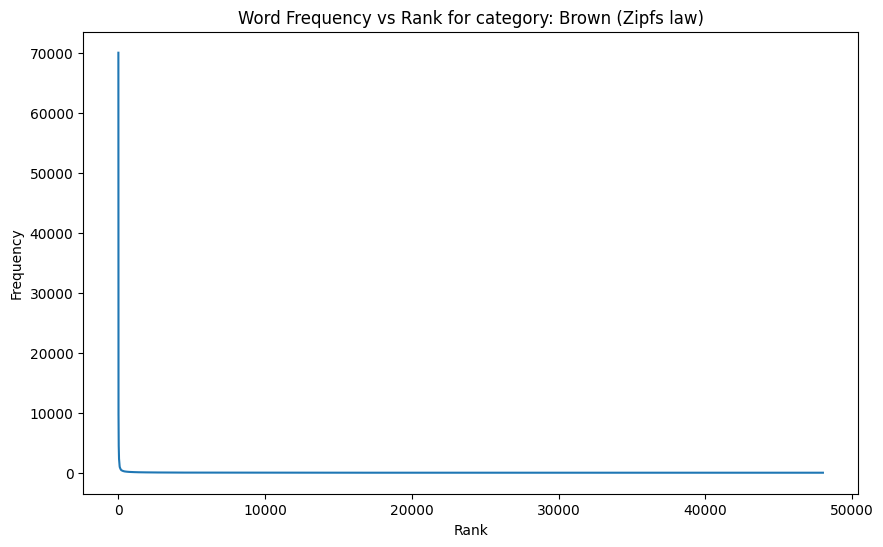

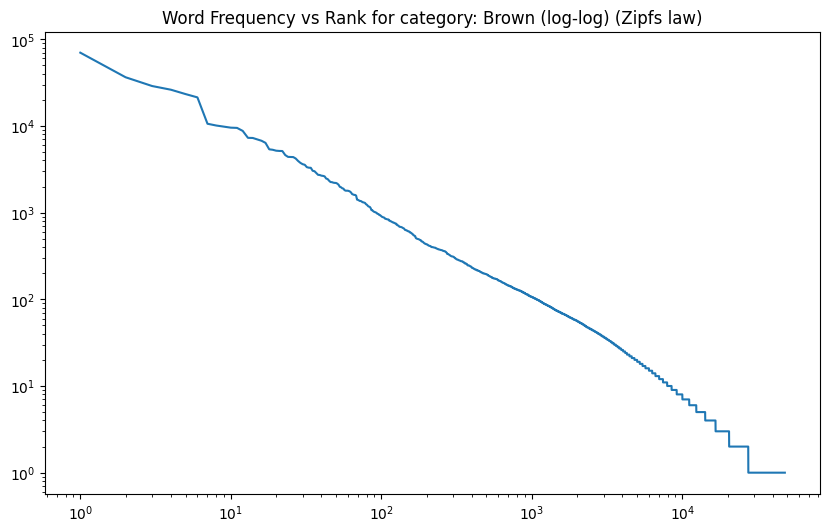

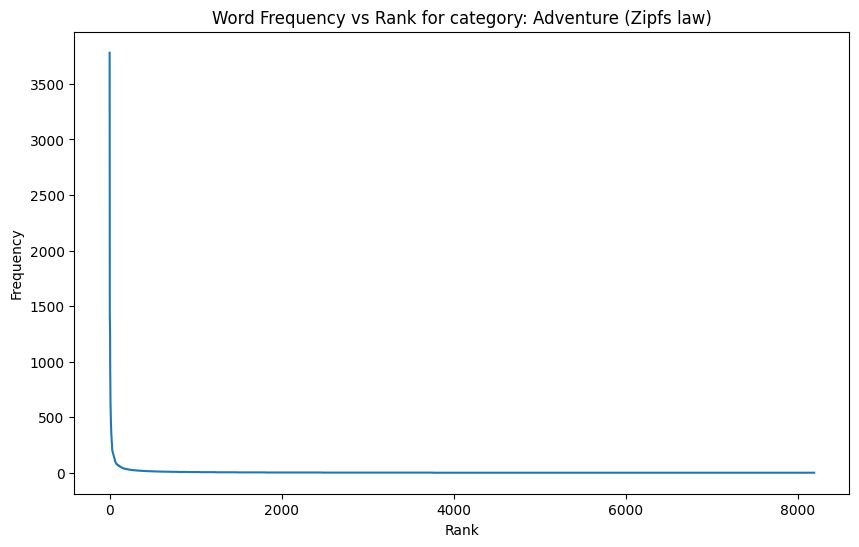

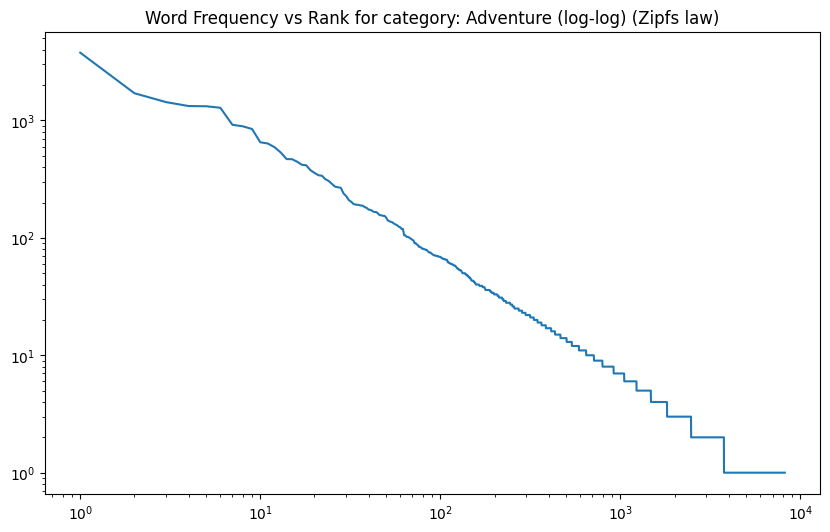

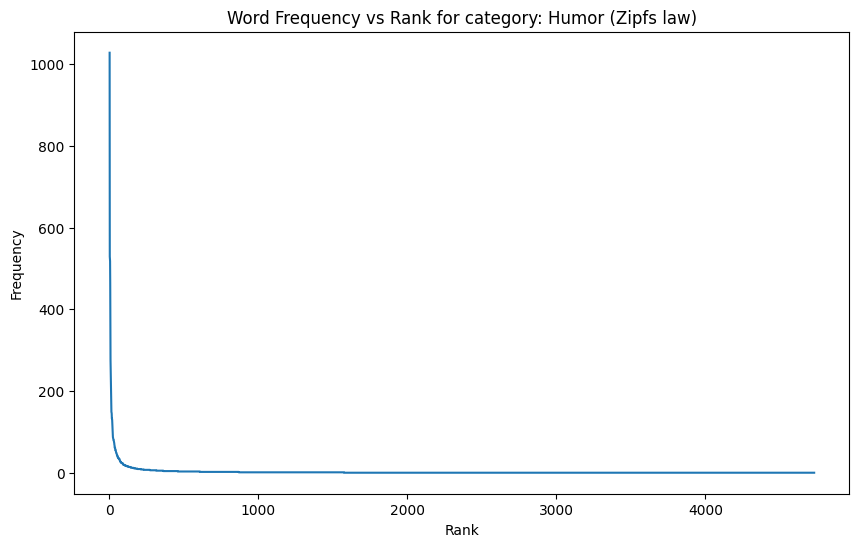

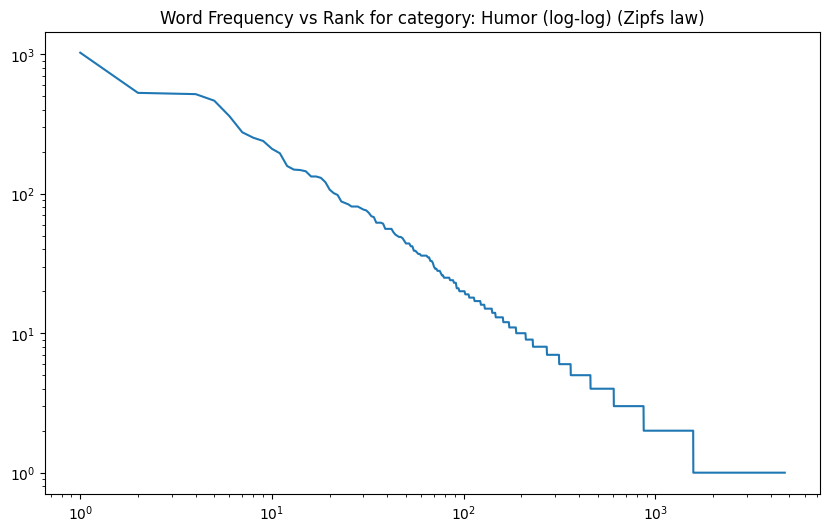

In [26]:
import matplotlib.pyplot as plt

def plot_regular(text, cat:str):
    word_freq = retrieve_descending_freq(text)
    # retrieve rank
    indices = range(1, len(word_freq) + 1)
    frequencies = [count for _, count in word_freq] #already sorted

    plt.figure(figsize=(10, 6))
    plt.plot(indices, frequencies)
    plt.xlabel('Rank')
    plt.ylabel('Frequency')
    plt.title(f'Word Frequency vs Rank for category: {cat} (Zipfs law)')
    plt.show()

def plot_loglog(text, cat:str):
    word_freq = retrieve_descending_freq(text)

    # retrieve rank
    indices = range(1, len(word_freq) + 1)
    frequencies = [count for _, count in word_freq] #already sorted

    plt.figure(figsize=(10, 6))
    plt.plot(indices, frequencies)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Word Frequency vs Rank for category: {cat} (log-log) (Zipfs law)')
    plt.show()

for cat, text in [('Brown', brown_text), ('Adventure', brown_adventure), ('Humor', brown_humor)]:
    plot_regular(text, cat)
    plot_loglog(text, cat)



## Step 5. 
Repeat the steps above for the Indian Language Corpus. Instead of comparing genres, choose
two languages to compare.

In [ ]:
# Load Indian Language language model
nltk.download('indian')
indian = nltk.corpus.indian
all_fileids_ind = indian.fileids()
root = indian.root  # path to indian 

indian_text = load_text(all_fileids_ind, root)
hindi_text = indian.raw('hindi.pos')
bangla_text = indian.raw('bangla.pos')

def ind_remove_tags(text):
    # first remove sentence tags
    # explicitly remove <Sentence id=x> and </Sentence>
    text = re.sub(r'</?Sentence[^>]*>', '', text)
    # split on space
    words_POS = text.split()
    # split on POS
    words = [word.rsplit('_', 1)[0] for word in words_POS] # max 2 items; take first item only
    return words

def ind_remove_nonwords(words: list[str]):
    # Remove punctuation marks
    mask = [
        bool(re.search(r'\w', word)) for word in words
    ]
    words_array = np.array(words)
    filtered_words = words_array[mask]
    return filtered_words.tolist()

def ind_count_unique_words(wordlist):
    # create a dictionary of word:count
    word_freqs = {}

    for word in wordlist:
        # count
        word_freqs[word] = word_freqs.get(word, 0) + 1 
    
    return word_freqs



[nltk_data] Downloading package indian to /Users/Gileesa/nltk_data...
[nltk_data]   Package indian is already up-to-date!


In [ ]:

def ind_retrieve_descending_freq(text):
    removed_tags = ind_remove_tags(text)
    removed_nonwords = ind_remove_nonwords(removed_tags)
    word_freq = ind_count_unique_words(removed_nonwords)
    return unique_list_of_words(word_freq)

def ind_retrieve_clean_words(text) -> list[str]:
    removed_tags = ind_remove_tags(text)
    removed_nonwords = ind_remove_nonwords(removed_tags)
    return list(removed_nonwords)

def ind_retrieve_sentences(text):
    return re.split(r'<Sentence id=\d+>', text)

def ind_number_of_tokens(text) -> int:
    # we assume the sentence start / end are also tokens
    # split on space
    words_POS = text.split()
    # split on POS
    words = [word.rsplit('_', 1)[0] for word in words_POS] # max 2 items; take first item only
    return len(words)

def ind_number_of_types(text) -> int:
    return len(ind_retrieve_descending_freq(text))

def ind_number_of_words(text) -> int:
    return len(ind_retrieve_clean_words(text))

def ind_avg_length_sentences(text) -> float:
    sentences = ind_retrieve_sentences(text)
    total_length = sum(len(ind_retrieve_clean_words(s)) for s in sentences)
    return total_length / len(sentences)

def ind_avg_word_length(text) -> float:
    wordlist = ind_retrieve_clean_words(text)
    return sum(len(word) for word in wordlist) / len(wordlist)

def ind_number_of_lemmas(text) -> int:
    ''' 
    This function does not actually count the number of lemmas, 
    but returns the number of words instead.
    This is because NLTK's WordNet lemmatiser is based on the English language
    and thus is of no use here.

    In addition, the authors do not understand any Indic scripts, so cannot
    create a lemmatiser themselves.

    An alternative solution might be using the iNLTK library.
    '''
    return ind_number_of_words(text)

for name, text in [('Indian (full)', indian_text), ('Hindi', hindi_text), ('Bangla', bangla_text)]:
    print(f"\n--- {name} ---")
    print(f"Tokens:               {ind_number_of_tokens(text)}")
    print(f"Types:                {ind_number_of_types(text)}")
    print(f"Words:                {ind_number_of_words(text)}")
    print(f"Avg words/sentence:   {ind_avg_length_sentences(text):.2f}")
    print(f"Avg word length:      {ind_avg_word_length(text):.2f}")
    print(f"Lemmas:               {ind_number_of_lemmas(text)}")


--- Indian (full) ---
Tokens:               59651
Types:                16124
Words:                42746
Avg words/sentence:   11.78
Avg word length:      5.53
Lemmas:               16124

--- Hindi ---
Tokens:               11032
Types:                2179
Words:                8751
Avg words/sentence:   16.18
Avg word length:      4.07
Lemmas:               2179

--- Bangla ---
Tokens:               12973
Types:                3624
Words:                8866
Avg words/sentence:   9.88
Avg word length:      4.93
Lemmas:               3624


In [ ]:

def ind_retrieve_tags(text) -> list[str]:
    words_POS = text.split()
    tags = [word.rsplit('_', 1)[1] for word in words_POS if '_' in word] # max 2 items; take 2nd item only
    return tags

def ind_frequent_tag(text) -> None:
    tags = ind_retrieve_tags(text)
    freq = Counter(tags)
    sorted_tags = sorted((set(tags)), key=lambda x: -freq[x])
    return sorted_tags
    
for cat, text in [('Indian (full)', indian_text), ('Hindi', hindi_text), ('Bangla', bangla_text)]:
    print(f"\n--- {cat} ---")
    print(ind_frequent_tag(text)[:10])


--- Indian (full) ---
['NN', 'SYM', 'VM', 'JJ', 'NNP', 'PRP', 'PREP', 'VAUX', 'VFM', 'CC']

--- Hindi ---
['PREP', 'NN', 'NNP', 'VFM', 'PUNC', 'VAUX', 'QFNUM', 'PRP', 'JJ', 'NNC']

--- Bangla ---
['NN', 'SYM', 'VM', 'PRP', 'JJ', 'NNP', 'VAUX', 'CC', 'PSP', 'XC']


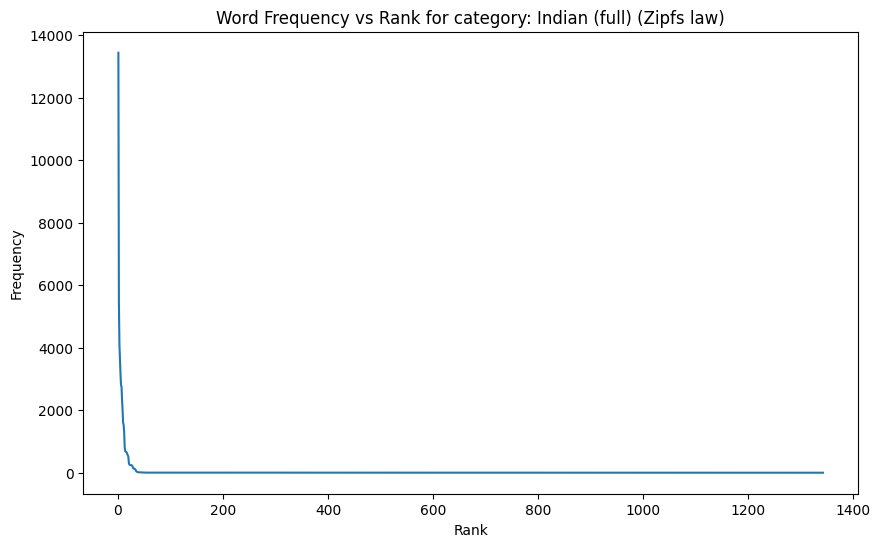

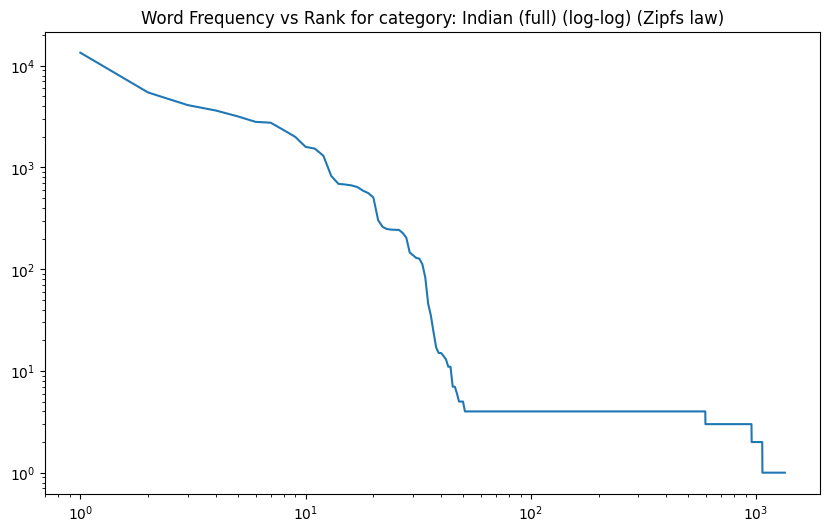

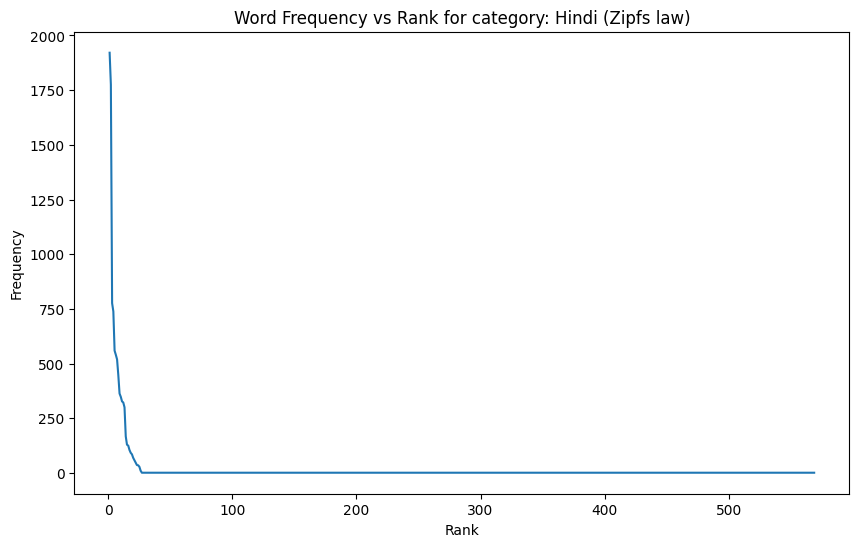

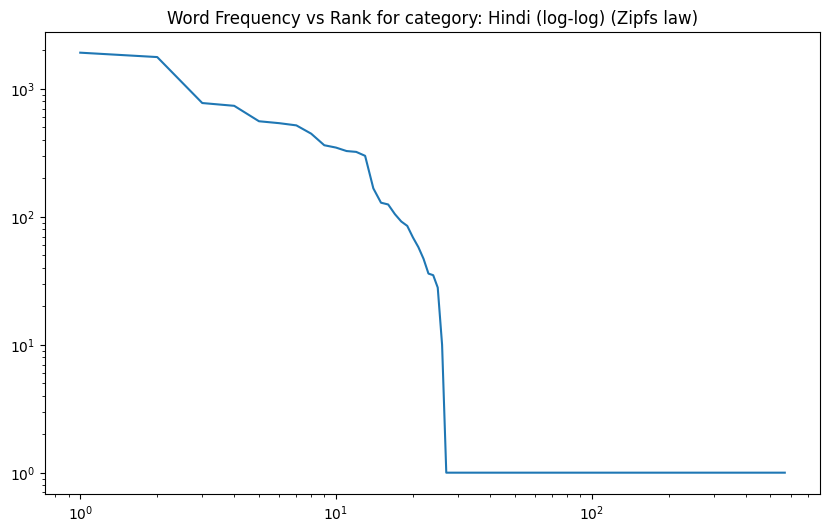

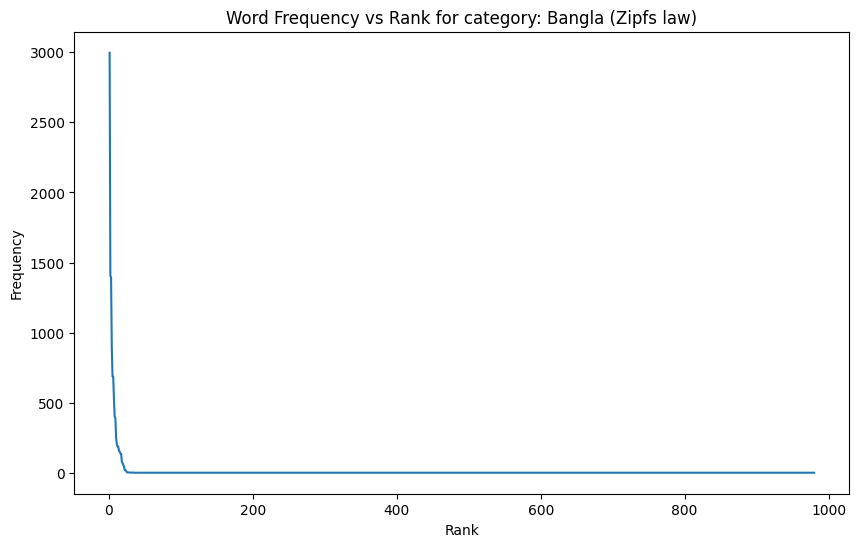

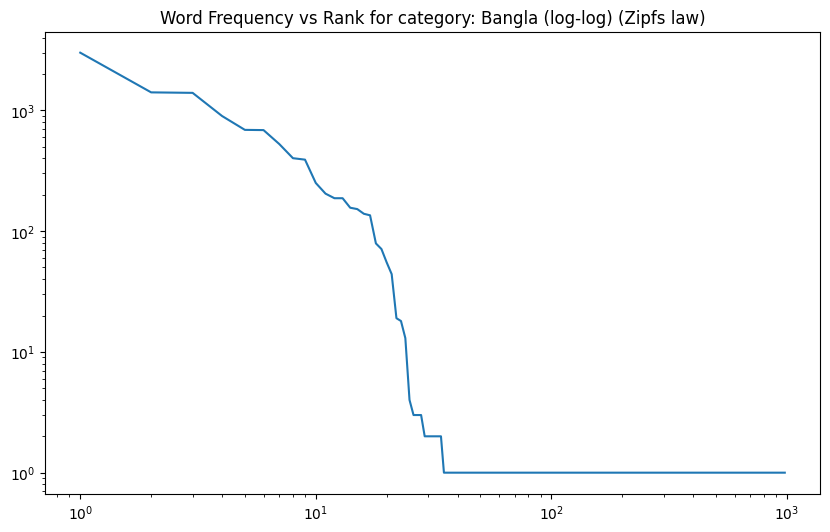

In [35]:
for cat, text in [('Indian (full)', indian_text), ('Hindi', hindi_text), ('Bangla', bangla_text)]:
    plot_regular(text, cat)
    plot_loglog(text, cat)